In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/dataset.csv")

print(df.head())




         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

In [12]:
print(df.head())
print("############")
print(df.columns)
print("############")
print(df.shape)
print("############")
print(df.dtypes)
print("############")
print(df.isnull().sum())
print("############")
print(df.describe())


         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

Dropping the cols

In [13]:
df.drop(columns=["Unnamed: 32"],inplace=True)
print(df.columns)

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='str')


In [14]:
print(df["diagnosis"].value_counts())
print(df["diagnosis"].value_counts(normalize=True) * 100)

df["diagnosis"] = df["diagnosis"].map({"M":1, "B": 0})

corr = df.corr()

print(corr["diagnosis"].sort_values(ascending=False))

diagnosis
B    357
M    212
Name: count, dtype: int64
diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64
diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactne

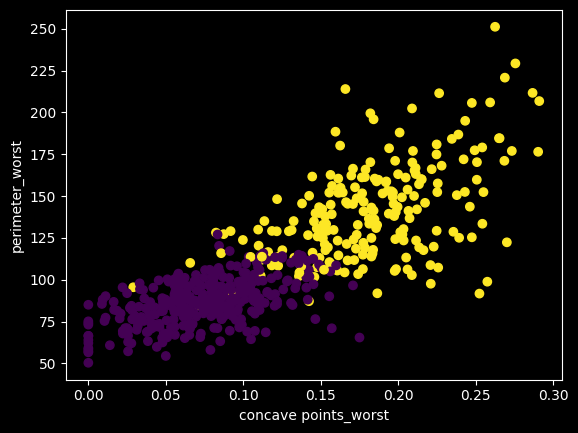

In [15]:
plt.scatter(df["concave points_worst"],
            df["perimeter_worst"],
            c=df["diagnosis"])

plt.xlabel("concave points_worst")
plt.ylabel("perimeter_worst")
plt.show()

Seperating target from feature

In [19]:
X = df.drop(["diagnosis"], axis=1)

X = X.select_dtypes(include = ['int64','float64'])
Y = df["diagnosis"]

Normalization

In [20]:
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)
X = (X-mean)/std;

spliting 8- 2- percent for traning and testing

In [21]:
split_index =int(0.8*len(X))
x_train = X[:split_index]
x_test = X[split_index:]

y_train = Y[:split_index]
y_test = Y[split_index:]

In [23]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(455, 31)
(114, 31)
(455,)
(114,)


Sigmoid Function

In [24]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


In [31]:
w = np.zeros(x_train.shape[1])
b = 0
z = np.dot(x_train,w) + b
y_hat = sigmoid(z)
print(y_hat[:5])

[0.5 0.5 0.5 0.5 0.5]


Log Loss.

In [32]:
def cost_function(X, y, w, b):
    m = len(y)
    z = np.dot(X,w) + b
    y_hat = sigmoid(z)
    cost = -np.sum(Y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat)) / m
    return cost



Gradient Descent

In [57]:
def gradient_descent(X,y,w,b,learning_rate,iterations):
    m = len(y)
    cost = []

    for i in range(iterations):
        z = np.dot(X,w) + b
        y_hat = sigmoid(z)
        error = y_hat - y

        dw_di = np.dot(X.T,error)/m
        db_di = np.sum(error) / m
        w = w - learning_rate * dw_di
        b = b - learning_rate * db_di

        cost.append(cost_function(X,y,w,b))

    return w,b,cost


In [34]:
m, n = X.shape

w = np.zeros(n)

b = 0

In [58]:
w, b, costs = gradient_descent(
    X,
    Y,
    w,
    b,
    learning_rate=0.01,
    iterations=1000
)

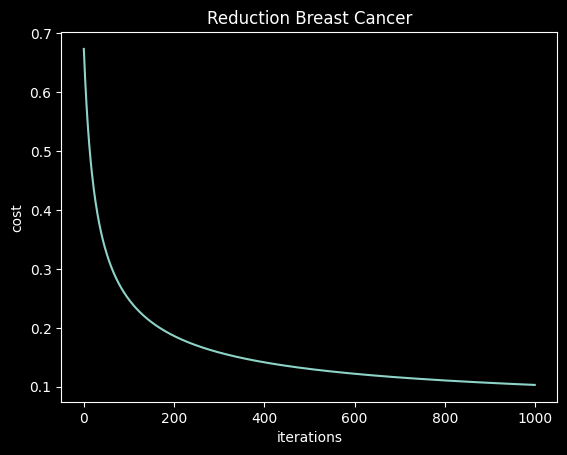

In [60]:
plt.plot(costs)
plt.xlabel("iterations")
plt.ylabel("cost")
plt.title("Reduction Breast Cancer")
plt.show()

In [61]:
perdication = (y_hat >= 0.1).astype(int)

In [63]:
z = np.dot(x_test,w) + b

y_hat = sigmoid(z)

predictions = (y_hat >= 0.5).astype(int)

accuracy = np.mean(predictions == y_test) * 100

print("Test Accuracy:", accuracy,"%")

Test Accuracy: 98.24561403508771 %


In [65]:
tp = np.sum((predictions == 1)  & (y_test == 1))
tn = np.sum((predictions == 0) & (y_test == 0))
fp = np.sum((predictions == 1) & (y_test == 0))
fn = np.sum((predictions == 0) & (y_test == 1))

print(tp,tn,fp,fn)


25 87 1 1


In [68]:
percision =tp/(tp + fp) * 100
print(percision,'%')

96.15384615384616 %


In [70]:
recall =tp /(tp + fn) * 100
print(recall,"%")

96.15384615384616 %


In [71]:
f1 = 2 * (percision* recall) / (percision + recall)

print("F1 Score:", f1)

F1 Score: 96.15384615384616


Metric	    Score
Accuracy	98.24%
Precision	96.15%
Recall	    96.15%
F1 Score	96.15%